In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [4]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(42000, 785)

In [7]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
25231,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
import matplotlib.pyplot as plt



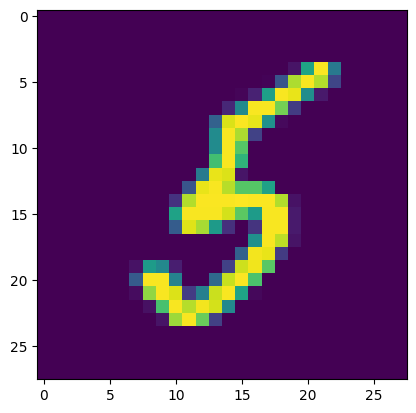

In [9]:
plt.imshow(df.iloc[3385, 1:].values.reshape(28,28))

In [10]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
X_train.shape

(33600, 784)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
knn = KNeighborsClassifier()

In [15]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [16]:
import time 
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

12.323993444442749


In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9648809523809524

In [18]:
from sklearn.preprocessing import StandardScaler 

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
X_train.shape

(33600, 784)

In [22]:
#PCA

In [23]:
from sklearn.decomposition import PCA

In [24]:
#Selcting only top 100 principal components
pca = PCA(n_components = 100) 

In [33]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [34]:
X_train_trf.shape

(33600, 100)

In [35]:
X_train.shape

(33600, 784)

In [36]:
knn = KNeighborsClassifier()

In [37]:
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [38]:
y_pred = knn.predict(X_test_trf)

In [39]:
accuracy_score(y_test, y_pred)

0.9548809523809524

In [ ]:
for i in range(1, 785):
    pca = PCA(n_components = i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)
    print(accuracy_score(y_test, y_pred))

0.2719047619047619
0.42238095238095236
0.485
0.6194047619047619
0.7297619047619047
0.8189285714285715
0.8664285714285714
0.8939285714285714
0.9075
0.9246428571428571
0.9315476190476191
0.9421428571428572
0.9492857142857143
0.9538095238095238
0.954047619047619
0.958452380952381
0.9616666666666667
0.9621428571428572
0.9645238095238096
0.9658333333333333
0.9661904761904762
0.9683333333333334
0.9696428571428571
0.9701190476190477
0.9704761904761905
0.9707142857142858
0.9708333333333333
0.9705952380952381
0.9709523809523809
0.9719047619047619
0.9723809523809523
0.9722619047619048
0.9708333333333333
0.9714285714285714
0.9713095238095238
0.9714285714285714
0.9725
0.9717857142857143
0.9728571428571429
0.9725
0.9720238095238095
0.9721428571428572
0.9725
0.9720238095238095
0.9719047619047619
0.971547619047619
0.9728571428571429
0.9735714285714285
0.973452380952381
0.9728571428571429
0.9726190476190476
0.9727380952380953
0.9725
0.9723809523809523
0.9728571428571429
0.9729761904761904
0.9730952380

In [40]:
#transforming to 2D coordinate system
pca = PCA(n_components = 2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [41]:
X_train_trf

array([[-2.71860179, -0.48971284],
       [-0.67698236, -6.75331325],
       [-3.03325838,  6.50947782],
       ...,
       [ 2.14878296,  0.78043289],
       [ 1.05962556,  0.94774034],
       [17.70263759,  1.96198163]])

In [42]:
import plotly.express as px

y_train_trf = y_train.astype(str)
fig = px.scatter(x = X_train_trf[:,0],
                y = X_train_trf[:,1],
                color = y_train_trf,
                color_discrete_sequence = px.colors.qualitative.G10
                )

fig.show()

In [43]:
#transforming to 3D coordinate system
pca = PCA(n_components = 3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [44]:
X_train_trf

array([[-2.71857382, -0.48924652,  1.13638551],
       [-0.67695682, -6.75368309, -2.33613168],
       [-3.03328854,  6.50982031,  7.49254568],
       ...,
       [ 2.14882719,  0.78093297, -0.74712291],
       [ 1.05963057,  0.94839685,  3.95059521],
       [17.70264618,  1.96176599, -4.94452575]])

In [49]:
import plotly.express as px

y_train_trf = y_train.astype(str)
fig = px.scatter(x = X_train_trf[:,0],
                y = X_train_trf[:,1],
                z = X_train_trf[:,2],
                color = y_train_trf)
fig.update_layout(
    margin = dict(l = 20, r = 20, t = 20, b = 20)
)

fig.show()

TypeError: scatter() got an unexpected keyword argument 'z'

In [53]:
#Eigen Values
pca.explained_variance_

array([40.67111197, 29.17023384, 26.74459506])

In [52]:
#Eigen Vectors
pca.components_

array([[ 4.13687252e-18, -6.29117224e-19, -1.40081780e-20, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 7.90896326e-17,  3.76960057e-17, -5.91844378e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-2.30687875e-17,  5.47920928e-17, -1.75885022e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [54]:
pca.components_.shape

(3, 784)

In [56]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [ ]:
#Finding Optimum number of Principal Components on this MNIST dataset

In [57]:
pca = PCA(n_components = None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [59]:
pca.explained_variance_.shape

(784,)

In [60]:
pca.components_

array([[-1.50074992e-19, -0.00000000e+00, -5.55111512e-17, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-3.77002386e-20,  1.04083409e-17,  6.93889390e-18, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 9.53221129e-20, -1.38777878e-17,  1.38777878e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-0.00000000e+00, -3.43757698e-02,  7.17831898e-02, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 0.00000000e+00,  1.00776447e-02, -7.19723645e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.88943875e-02, -3.41427547e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [61]:
pca.components_.shape

(784, 784)

In [64]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

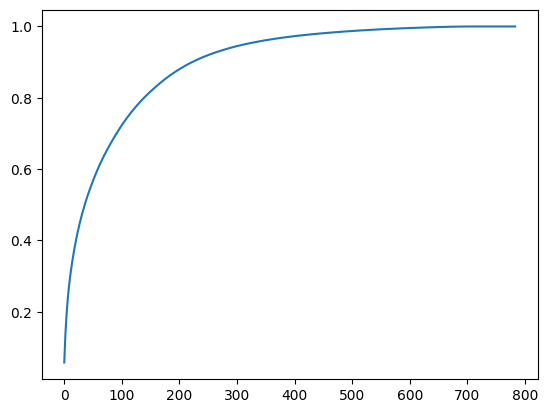

In [65]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))